In [1]:
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import os
os.environ['ESMFMKFILE'] = 'C:/Users/eving/AppData/Local/miniconda3/envs/evalprecextremes/Library/lib/esmf.mk'
import xesmf as xe
import numpy as np
np.float_ = np.float64
import matplotlib.colors as mcolors
from clisops.core import subset
from metpy.plots import ctables
import matplotlib.ticker as ticker
import cmaps
import geopandas as gpd
import seaborn as sns
import rioxarray
from math import nan
from scipy import stats
import statsmodels.api as sm
import cartopy

levels_1h = np.linspace(12, 42, 16)
levels_24h = np.linspace(40, 210, 18)

# nc files provided by Ben Poschlod 04/05/2026

### Poschlod, B., Ludwig, R., and Sillmann, J.: Ten-year return levels of sub-daily extreme precipitation over Europe, Earth Syst. Sci. Data, 13, 983–1003, https://doi.org/10.5194/essd-13-983-2021, 2021

In [4]:
folder = "D:/EUROCORDEX_extremes/10yrRL_BenPosch/"

# Estimates of the 10-year return levels for the RCM simulations

### 1-hourly

c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


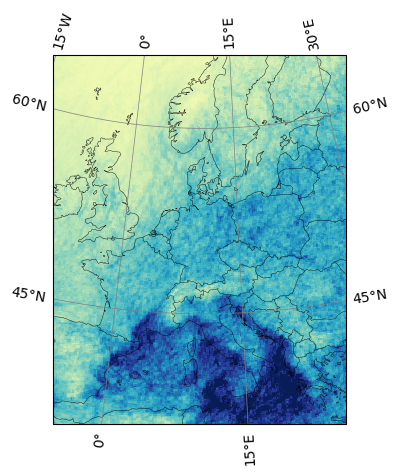

In [9]:
# Original Projection
projorig_name  = "PlateCarree"
projorig_dict  = dict()
projorig       = ccrs.__dict__[projorig_name].__call__(**projorig_dict)


# Graphic projection
projplot       = "LambertConformal"
projplot_dict  = dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45))
projplot       = ccrs.__dict__[projplot].__call__(**projplot_dict)

# loadtxt is fast for simple numeric files
fMod = "matrix_10yrRL_1hr_ALARO1-SFX.csv"
RLMod = np.loadtxt(folder+fMod, delimiter=',')

fMod = f'D:/EUROCORDEX_extremes/figures_24Apr/precip_simplescaling_ERA5_ALARO1-SFX_JJA.nc'
dsMod = xr.load_dataset(fMod, engine="netcdf4")

X = dsMod.lon.values
Y = dsMod.lat.values

ax = plt.axes(projection=projplot, transform = projorig)
ax.set_global()
ax.set_extent([-5, 25, 35, 65], crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.BORDERS, linewidth=0.3, color='black')
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', xlocs=range(-180,180,15), ylocs=range(-90,90,15),x_inline=False,y_inline=False)
ax.coastlines(resolution='50m', linewidth=0.3, color='black')
ax.pcolormesh(X, Y, RLMod, cmap="YlGnBu", vmin=3,vmax=30, transform=projorig)

### Daily return levels

c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


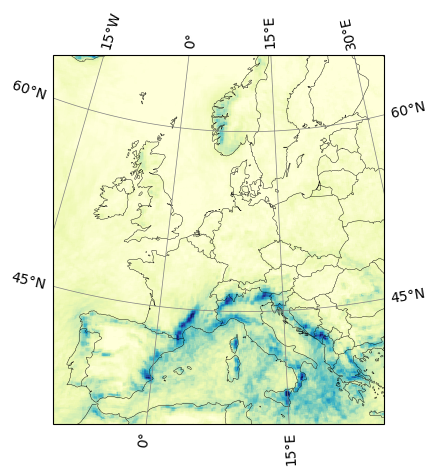

In [11]:
# loadtxt is fast for simple numeric files
fMod = "matrix_10yrRL_24hr_ALARO1-SFX.csv"
RLMod = np.loadtxt(folder+fMod, delimiter=',')

fMod = f'D:/EUROCORDEX_extremes/figures_24Apr/precip_simplescaling_ERA5_ALARO1-SFX_JJA.nc'
dsMod = xr.load_dataset(fMod, engine="netcdf4")

X = dsMod.lon.values
Y = dsMod.lat.values

ax = plt.axes(projection=projplot, transform = projorig)
ax.set_global()
ax.set_extent([-10, 25, 35, 65], crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.BORDERS, linewidth=0.3, color='black')
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', xlocs=range(-180,180,15), ylocs=range(-90,90,15),x_inline=False,y_inline=False)
ax.coastlines(resolution='50m', linewidth=0.3, color='black')
ax.pcolormesh(X, Y, RLMod, cmap="YlGnBu", vmin=40,vmax=210, transform=projorig)

c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


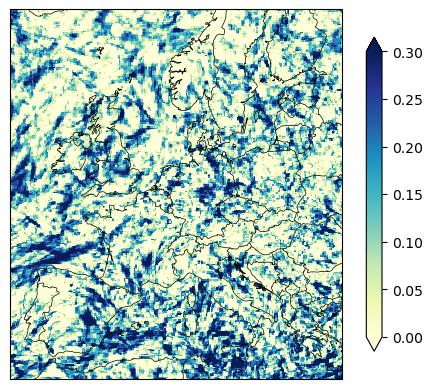

In [13]:
# loadtxt is fast for simple numeric files
fMod = "matrix_shape_24hr_ALARO1-SFX.csv"
shape = np.loadtxt(folder+fMod, delimiter=',')

fMod = f'D:/EUROCORDEX_extremes/figures_24Apr/precip_simplescaling_ERA5_ALARO1-SFX_JJA.nc'
dsMod = xr.load_dataset(fMod, engine="netcdf4")

X = dsMod.lon.values
Y = dsMod.lat.values

ax = plt.axes(projection=projplot, transform = projorig)
ax.set_global()
ax.set_extent([-10, 25, 35, 65], crs=ccrs.PlateCarree())
plot = ax.pcolormesh(X, Y, shape, cmap="YlGnBu", vmin=0,vmax=0.3, transform=projorig)
ax.add_feature(cartopy.feature.BORDERS, linewidth=0.5, color='black')
ax.coastlines(resolution='50m', linewidth=0.5, color='black')

# Add a colorbar axis at the bottom of the graph
plt.colorbar(plot, ax=ax, orientation='vertical', shrink=0.85, pad=0.05, extend="both")
        

# Reference return levels

# Compute lon/lat from rotated coordinates for the reference dataset

In [3]:
def unrot_lon(rlat, rlon, pole_lat, pole_lon):
    """
    Transform rotated longitude to regular non-rotated longitude lon(2D).
    """
    nrlat = np.shape(rlat)
    nrlon = np.shape(rlon)

    nrlat_rank = np.ndim(nrlat)
    nrlon_rank = np.ndim(nrlon)

    if(np.any(nrlat != nrlon) and (nrlat_rank != 1 or nrlon_rank != 1)):
        print("Function unrot_lon: rlat and rlon dimensions do not match")
        exit()

    if(nrlat_rank == 1 and nrlon_rank == 1):
        rlo = np.tile(rlon, (nrlat[0],1))
        rla = np.transpose([rlat]*nrlon[0])
    else:
        rla = rlat
        rlo = rlon

    rla = np.deg2rad(rla)
    rlo = np.deg2rad(rlo)

    s1 = np.sin(np.deg2rad(pole_lat))
    c1 = np.cos(np.deg2rad(pole_lat))
    s2 = np.sin(np.deg2rad(pole_lon))
    c2 = np.cos(np.deg2rad(pole_lon))

    tmp1 = s2*(-s1*np.cos(rlo)*np.cos(rla)+c1*np.sin(rla))-c2*np.sin(rlo)*np.cos(rla)
    tmp2 = c2*(-s1*np.cos(rlo)*np.cos(rla)+c1*np.sin(rla))+s2*np.sin(rlo)*np.cos(rla)

    lon = np.rad2deg(np.arctan(tmp1/tmp2))

    print('Function unrot_lon: min/max  %f / %f' % (np.min(lon[0,:]), np.max(lon[0,:])) )

    return lon

def unrot_lat(rlat, rlon, pole_lat, pole_lon):
    """
    Transform rotated latitude to regular non-rotated latitude lat(2D)
    """
    nrlat = np.shape(rlat)
    nrlon = np.shape(rlon)

    nrlat_rank = np.ndim(nrlat)
    nrlon_rank = np.ndim(nrlon)

    if(np.any(nrlat != nrlon) and (nrlat_rank != 1 or nrlon_rank != 1)):
        print("Function unrot_lat: rlat and rlon dimensions do not match")
        exit()

    if(nrlat_rank == 1 and nrlon_rank == 1):
        rlo = np.tile(rlon, (nrlat[0],1))
        rla = np.transpose([rlat]*nrlon[0])
    else:
        rla = rlat
        rlo = rlon

    rla = np.deg2rad(rla)
    rlo = np.deg2rad(rlo)

    s1 = np.sin(np.deg2rad(pole_lat))
    c1 = np.cos(np.deg2rad(pole_lat))

    lat = s1*np.sin(rla)+c1*np.cos(rla)*np.cos(rlo)
    lat = np.rad2deg(np.arcsin(lat))

    print('Function unrot_lat: min/max  %f / %f' % (np.min(lat[0,:]), np.max(lat[0,:])) )

    return lat

Function unrot_lon: min/max  -6.200426 / 28.357166
Function unrot_lat: min/max  30.427963 / 33.975002


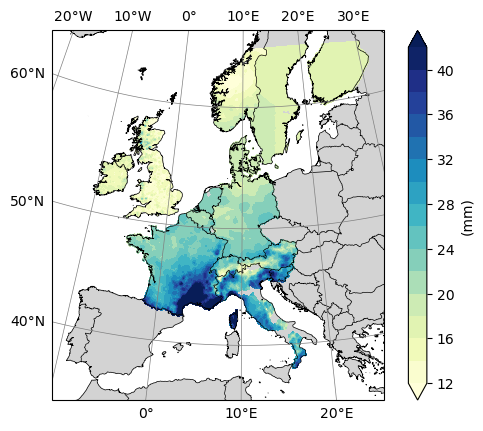

In [5]:
fObs = "return_levels_10a_1h.nc"
dsObs = xr.load_dataset(folder+fObs, engine="netcdf4")
var  = dsObs.return_levels_10a_1h
rlat = dsObs.rlat
rlon = dsObs.rlon
pole_lon = -162
pole_lat = 39.25

lon = unrot_lon(rlat, rlon, pole_lat, pole_lon)
lat = unrot_lat(rlat, rlon, pole_lat, pole_lon)

# Original Projection
projorig_name  = "PlateCarree"
projorig_dict  = dict()
projorig       = ccrs.__dict__[projorig_name].__call__(**projorig_dict)

# Graphic projection
projplot_name       = "LambertConformal"
projplot_dict  = dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45))
projplot       = ccrs.__dict__[projplot_name].__call__(**projplot_dict)

ax = plt.axes(projection=projplot, transform = projorig)
ax.set_global()

ax.set_extent([-10, 25, 35, 65], crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.OCEAN, color='white', zorder=0)
ax.add_feature(cartopy.feature.LAND, color='lightgray',zorder=0,
                linewidth=0.5, edgecolor='black')
gls = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', xlocs=range(-180,180,10), ylocs=range(-90,90,10),
             x_inline=False,y_inline=False,rotate_labels = False)
gls.right_labels = False
p0 = ax.contourf(lon, lat, var, cmap="YlGnBu", levels=levels_1h, transform=projorig, extend = "both")

# Add fine resolution borders
# Category: 'cultural', Name: 'admin_0_boundary_lines_land', Scale: '10m'
fine_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='10m',
    facecolor='none'
)
ax.add_feature(fine_borders, edgecolor='black', linewidth=0.5)

# Optional: Add coastlines at 10m
ax.coastlines(resolution='10m', linewidth=0.5)

plt.colorbar(p0, ax=ax, orientation='vertical', label='(mm)') 


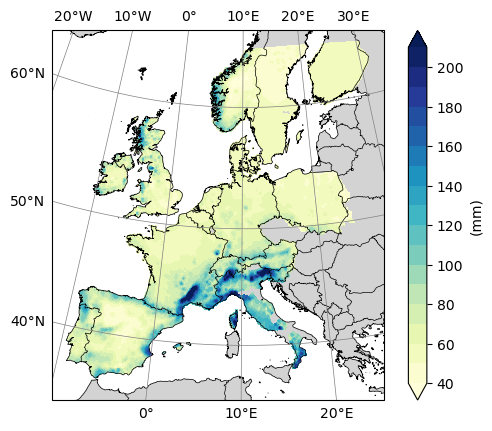

In [6]:
import cartopy.feature as cf
from google_crc32c import extend
from narwhals import col

fObs = "return_levels_10a_24h.nc"
dsObs = xr.load_dataset(folder+fObs, engine="netcdf4")

var  = dsObs.return_levels_10a_24h

ax = plt.axes(projection=projplot, transform = projorig)
ax.set_global()
ax.set_extent([-10, 25, 35, 65], crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.OCEAN, color='white', zorder=0)
ax.add_feature(cartopy.feature.LAND, color='lightgray',zorder=0,
                linewidth=0.5, edgecolor='black')
gls = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', xlocs=range(-180,180,10), ylocs=range(-90,90,10),
             x_inline=False,y_inline=False,rotate_labels = False)
gls.right_labels = False
p0=ax.contourf(lon, lat, var, levels=levels_24h, cmap="YlGnBu", transform=projorig, extend = "both")

# Add fine resolution borders
# Category: 'cultural', Name: 'admin_0_boundary_lines_land', Scale: '10m'
fine_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='10m',
    facecolor='none'
)
ax.add_feature(fine_borders, edgecolor='black', linewidth=0.5)

# Optional: Add coastlines at 10m
ax.coastlines(resolution='10m', linewidth=0.5)


plt.colorbar(p0, ax=ax, orientation='vertical', label='(mm)')


# Biais relatifs des niveaux de retour 10 ans

In [ ]:
folder = 'D:/EUROCORDEX_extremes/DATA/10yrRL_BenPosch/'

# list models and obs
name_models = ['ERA5_CNRM-ALADIN64E1','ERA5_ALARO1-SFX','ERA5_CCLM6-0-1',
            'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
            'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']

label_models = ['ALADIN64E1','ALARO1-SFX','CCLM6-0-1',
            'HCLIM43','ICON-CLM','RACMO23E',
            'RegCM5-0','REMO2020','WRF451Q']
# Original Projection
projorig_name  = "PlateCarree"
projorig_dict  = dict()
projorig       = ccrs.__dict__[projorig_name].__call__(**projorig_dict)

# Graphic projection
projplot_name       = "LambertConformal"
projplot_dict  = dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45))
projplot       = ccrs.__dict__[projplot_name].__call__(**projplot_dict)

for diff in ['rel','abs']:
    for time_scale in ['1','3','6','12','24']:
        # Initialiser la figure et les axes
        fig, axes = plt.subplots(nrows=3, ncols=3, subplot_kw={'projection': projplot},figsize=(8,9))

        fObs = f"return_levels_10a_{time_scale}h.nc"
        dsObs = xr.load_dataset(folder+fObs, engine="netcdf4")
        var  = dsObs[f'return_levels_10a_{time_scale}h']
        rlat = dsObs.rlat
        rlon = dsObs.rlon
        pole_lon = -162
        pole_lat = 39.25
        lon = unrot_lon(rlat, rlon, pole_lat, pole_lon)
        lat = unrot_lat(rlat, rlon, pole_lat, pole_lon)

        dsObs_clean = xr.Dataset(
            data_vars={"RL": (("y", "x"), var.values)},
            coords={
                "x": rlon,
                "y": rlat,
                "lon": (("y", "x"), lon),
                "lat": (("y", "x"), lat),
            }
        )

        dsObs_clean = dsObs_clean.cf.add_bounds(["lon","lat"])


        for ax, model in zip(axes.flat, name_models):
                # loadtxt is fast for simple numeric files
            fMod = f"matrix_10yrRL_{time_scale}hr_{model}.csv"
            var = np.loadtxt(folder+fMod, delimiter=',')

            fMod = f'D:/EUROCORDEX_extremes/FIGURES/SIMPLESCALING/precip_simplescaling_{model}_JJA.nc'
            dsMod = xr.load_dataset(fMod, engine="netcdf4")
            dsMod_clean = xr.Dataset(
                data_vars={"RL": (("y", "x"), var)},
                coords={
                    "x": dsMod.x,
                    "y": dsMod.y,
                    "lon": (("y", "x"), dsMod.lon.values),
                    "lat": (("y", "x"), dsMod.lat.values),
                }
            )
            dsMod_clean = dsMod_clean.cf.add_bounds(["lon","lat"])
            
            # regrid obs
            regridder = xe.Regridder(
                dsMod_clean, dsObs_clean, "conservative", unmapped_to_nan=True, ignore_degenerate=True
            )
            dsMod_regrid = regridder(dsMod_clean, keep_attrs=True)

            X = dsObs_clean.lon
            Y = dsObs_clean.lat
            ZOBS = dsObs_clean.RL
            ZMOD = dsMod_regrid.RL
            
            if(diff=="rel"):
                Z = (ZMOD / ZOBS - 1) * 100 # Calculate percentage difference
                plot = ax.pcolormesh(X, Y, Z, cmap=cmaps.precip_diff_12lev, vmin=-65, vmax=65,
                                transform=projorig, zorder=1)
            else:
                Z = ZMOD - ZOBS
                plot = ax.pcolormesh(X, Y, Z, cmap=cmaps.precip_diff_12lev, vmin=-32.5, vmax=32.5,
                                transform=projorig, zorder=1)
            
            # draw coastlines and borders
            ax.set_extent([-10, 25, 35, 65], crs=ccrs.PlateCarree())
            ax.add_feature(cartopy.feature.OCEAN, color='white', zorder=0)
            ax.add_feature(cartopy.feature.LAND, color='lightgray',zorder=0,
                linewidth=0.5, edgecolor='black')
            
            # Add fine resolution borders
            # Category: 'cultural', Name: 'admin_0_boundary_lines_land', Scale: '10m'
            fine_borders = cfeature.NaturalEarthFeature(
                category='cultural',
                name='admin_0_boundary_lines_land',
                scale='10m',
                facecolor='none'
            )
            ax.add_feature(fine_borders, edgecolor='black', linewidth=0.5)

            # Optional: Add coastlines at 10m
            ax.coastlines(resolution='10m', linewidth=0.5)

            # add model name
            ax.set_title(label_models[name_models.index(model)], fontsize=14, pad=1.0)

        # Adjust the location of the subplots on the page to make room for the colorbar
        fig.subplots_adjust(right=0.9)
        
        # Add a colorbar axis at the bottom of the graph
        cbar_ax = fig.add_axes([0.92, 0.25, 0.03, 0.5]) #[left, bottom, width, height]
        cbar = fig.colorbar(plot, cax=cbar_ax,orientation='vertical',shrink=0.85, pad=0.05, extend = "both")
        if diff == "rel":
            cbar.set_label("Relative difference (%)", fontsize=12)
        else:
            cbar.set_label("Absolute difference (mm)", fontsize=12)

        cbar.ax.tick_params(labelsize=12)

        fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)

        # save the figure
        plt.savefig(f'D:/EUROCORDEX_extremes/FIGURES/DIFF_RL10/10yrRL_{time_scale}_{diff}diff.png', dpi=300, bbox_inches='tight')
        plt.close()

Function unrot_lon: min/max  -6.200426 / 28.357166
Function unrot_lat: min/max  30.427963 / 33.975002


c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\frontend.py:95: UserWarning: Variables {'rlon_bnds', 'rlat_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\frontend.py:96: UserWarning: Variables {'rlon_bnds', 'rlat_bnds'} not found in object but are referred to in the CF attributes.
  lat_bnds = ds.cf.get_bo

Function unrot_lon: min/max  -6.200426 / 28.357166
Function unrot_lat: min/max  30.427963 / 33.975002


c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\frontend.py:95: UserWarning: Variables {'rlon_bnds', 'rlat_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\frontend.py:96: UserWarning: Variables {'rlon_bnds', 'rlat_bnds'} not found in object but are referred to in the CF attributes.
  lat_bnds = ds.cf.get_bo

Function unrot_lon: min/max  -6.200426 / 28.357166
Function unrot_lat: min/max  30.427963 / 33.975002


...

c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\frontend.py:95: UserWarning: Variables {'rlon_bnds', 'rlat_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\frontend.py:96: UserWarning: Variables {'rlon_bnds', 'rlat_bnds'} not found in object but are referred to in the CF attributes.
  lat_bnds = ds.cf.get_bo

Function unrot_lon: min/max  -6.200426 / 28.357166
Function unrot_lat: min/max  30.427963 / 33.975002


c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\frontend.py:95: UserWarning: Variables {'rlon_bnds', 'rlat_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\frontend.py:96: UserWarning: Variables {'rlon_bnds', 'rlat_bnds'} not found in object but are referred to in the CF attributes.
  lat_bnds = ds.cf.get_bo

Function unrot_lon: min/max  -6.200426 / 28.357166
Function unrot_lat: min/max  30.427963 / 33.975002


c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\frontend.py:95: UserWarning: Variables {'rlon_bnds', 'rlat_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\frontend.py:96: UserWarning: Variables {'rlon_bnds', 'rlat_bnds'} not found in object but are referred to in the CF attributes.
  lat_bnds = ds.cf.get_bo